In [42]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # must be FIRST, before torch


import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [43]:
def build_and_train(X, y):
    # build model
    ANNreg = nn.Sequential(
        nn.Linear(1, 1),  # input layer
        nn.ReLU(),  # activation function
        nn.Linear(1, 1),  # output layer
    )

    # parameters
    learning_rate = 0.05
    loss_fun = nn.MSELoss()
    optimizer = torch.optim.SGD(ANNreg.parameters(), lr=learning_rate)

    # train the model
    numepochs = 500

    losses = torch.zeros(numepochs)

    for epochi in range(numepochs):
        # forward pass
        yHat = ANNreg(X)

        # compute loss
        loss = loss_fun(yHat, y)
        losses[epochi] = loss

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    prediction = ANNreg(X)
    return prediction, losses

In [44]:
def create_data(m, N):
    x = torch.randn(N, 1)
    y = m * x + torch.randn(N, 1) / 2

    return x, y

In [45]:
m = torch.linspace(-2, 2, 21)
numExps = 50
results = np.zeros((len(m), numExps, 2))

for slope in range(len(m)):
    for N in range(numExps):
        x, y = create_data(m[slope], N)
        prediction, losses = build_and_train(x, y)

        results[slope, N, 0] = losses[-1]
        results[slope, N, 1] = np.corrcoef(y.T, prediction.detach().T)[0, 1]

results[np.isnan(results)] = 0

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:

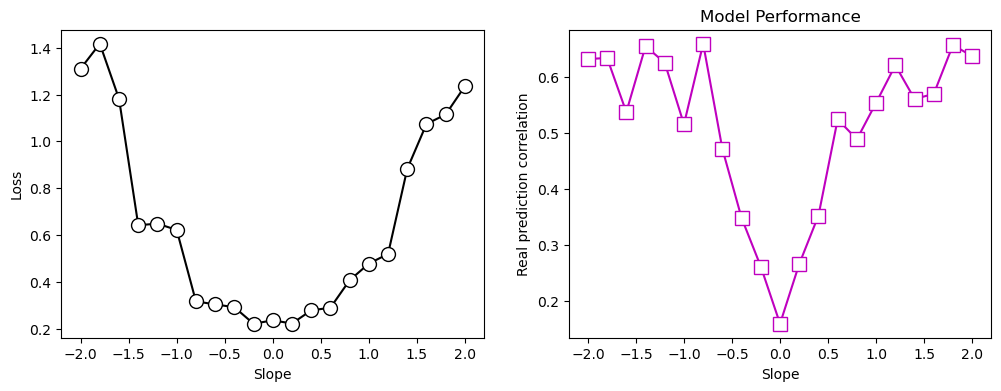

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(
    m, np.mean(results[:, :, 0], axis=1), "ko-", markerfacecolor="w", markersize=10
)
ax[0].set_xlabel("Slope")
ax[0].set_ylabel("Loss")


ax[1].plot(
    m, np.mean(results[:, :, 1], axis=1), "ms-", markerfacecolor="w", markersize=10
)
ax[1].set_xlabel("Slope")
ax[1].set_ylabel("Real prediction correlation")
ax[1].set_title("Model Performance")

plt.show()